In [3]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## New material

### Attributes

In [20]:
actors = Table.read_table('actors.csv')
actors

Actor,Total Gross,Number of Movies,Average per Movie,#1 Movie,Gross
Harrison Ford,4871.7,41,118.8,Star Wars: The Force Awakens,936.7
Samuel L. Jackson,4772.8,69,69.2,The Avengers,623.4
Morgan Freeman,4468.3,61,73.3,The Dark Knight,534.9
Tom Hanks,4340.8,44,98.7,Toy Story 3,415
"Robert Downey, Jr.",3947.3,53,74.5,The Avengers,623.4
Eddie Murphy,3810.4,38,100.3,Shrek 2,441.2
Tom Cruise,3587.2,36,99.6,War of the Worlds,234.3
Johnny Depp,3368.6,45,74.9,Dead Man's Chest,423.3
Michael Caine,3351.5,58,57.8,The Dark Knight,534.9
Scarlett Johansson,3341.2,37,90.3,The Avengers,623.4


### Some plots for numerical attributes

We will spend Thursday looking into the specifics of this data. For today, we'll just load it and make some visualizations with it.

In [8]:
census = Table.read_table('nc-est2019-agesex-res.csv')
census2019 = census.select('SEX', 'AGE', 'POPESTIMATE2019')
census2019 = census2019.relabeled(2, '2019')

**Task**: Plot the total population (in millions) as each age increases.

- Why 999 and why 0? We'll worry about these specifics on Thursday.

In [14]:
totals2019 = census2019.where('AGE',are.below(999)).where('SEX', 0)
totals2019 = totals2019.with_columns('Population (in millions)', totals2019.column('2019')/1e6) 

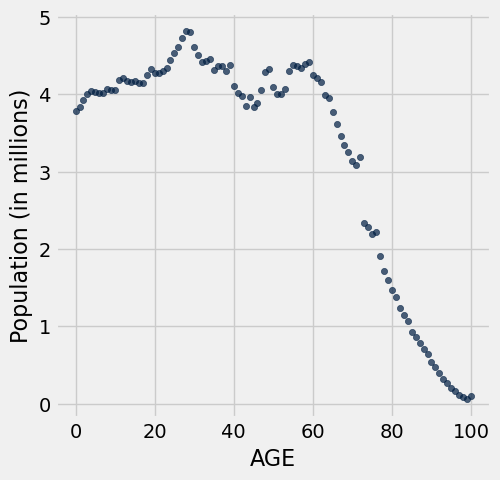

In [16]:
totals2019.scatter('AGE', 'Population (in millions)')

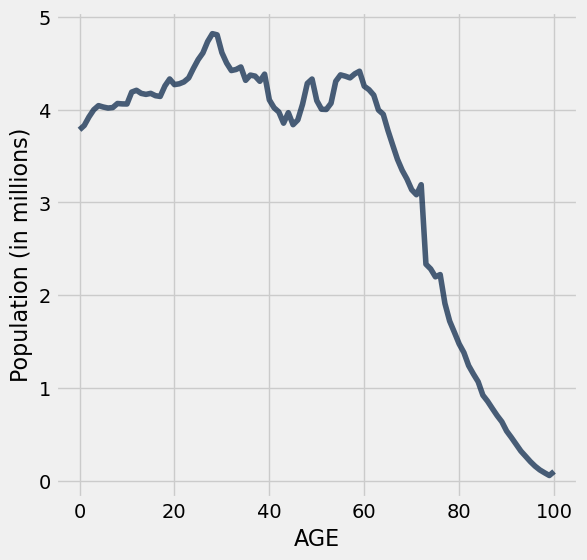

In [17]:
totals2019.plot('AGE', 'Population (in millions)')

_____

**Discussion [1 min]:** What are some things you notice from the below visualization? I see at least two! (1 min)

In [ ]:
full.select('AGE', 'SEX', 
            'POPESTIMATE2019', 'POPESTIMATE2011').where('AGE',
                                                        are.below(999)).where('SEX',
                                                                              0).drop('SEX').plot('AGE')


______

**Task:** Plot the relationship between the number of movies cast and average salary per movie among famous Hollywood actors.

In [ ]:
actors.plot('Number of Movies', 'Total Gross')

In [ ]:
actors.scatter('Number of Movies', 'Total Gross')

#### Investigate anomalies!!

In [ ]:
actors.scatter('Number of Movies', 'Average per Movie')

In [ ]:
actors.where('Average per Movie', are.above(400))

**STOP**

### Categorical attributes

In [23]:
# Highest grossing movies as of 2017
top_movies = Table.read_table('top_movies_2017.csv')
top_movies

Title,Studio,Gross,Gross (Adjusted),Year
Gone with the Wind,MGM,198676459,1796176700,1939
Star Wars,Fox,460998007,1583483200,1977
The Sound of Music,Fox,158671368,1266072700,1965
E.T.: The Extra-Terrestrial,Universal,435110554,1261085000,1982
Titanic,Paramount,658672302,1204368000,1997
The Ten Commandments,Paramount,65500000,1164590000,1956
Jaws,Universal,260000000,1138620700,1975
Doctor Zhivago,MGM,111721910,1103564200,1965
The Exorcist,Warner Brothers,232906145,983226600,1973
Snow White and the Seven Dwarves,Disney,184925486,969010000,1937


#### **Task**: Visualize the number of movies released by each studio.

In [ ]:
top_movies.group('Studio')

In [ ]:
top_movies.group('Studio').barh('Studio')

**Discussion [30 sec]:** How might this plot be improved to show a clearer message about the data? 

#### **Task**: Visualize the top 10 highest adjusted grossing movies by US dollars (in millions).

In [ ]:
top10_adjusted = top_movies.take(np.arange(10))
top10_adjusted

Convert to millions of dollars for readability

In [ ]:
millions = np.round(top10_adjusted.column('Gross (Adjusted)') / 1000000, 3)
top10_adjusted = top10_adjusted.with_column('Millions', millions)
top10_adjusted

In [ ]:
top10_adjusted.barh('Title', 'Millions')

### Challenge Task:
- Generate the chart shown in the slides: a bar chart of age (# years since release) for the 10 highest grossing movies (non-adjusted).

Discussion [1 min]

### Good visualization practices

#### Titling plots
- Just add a `print()` statement after your plotting code.

##### Fine title:

In [ ]:
total_below_999.plot('AGE', 'Population (in millions)')
print('US Population in 2019 by age')  

##### Better title:

In [ ]:
total_below_999.plot('AGE', 'Population (in millions)')
print('Population counts in 2019 show a steep decline around age 60')  